In [1]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import seaborn as sns
sns.set_theme(style="darkgrid")

from pm.data import download_prices, ath_summary, filter_min_obs
from pm.returns import compute_returns
from pm.visualization import plot_universe_dispersion

# Historical Price Data

**Prices Data Download:**

These tickers were part of my portfolio composition until August 2025, since then some positions have been closed and others opened based on earnings reports,<br>
economic trends, or just interest in different companies with higher risk/return expectations. As mentioned, this list of tickers is just an example of a stale portfolio universe <br> that can be improved and updated over time. 

In [2]:
tickers = ['NVDA','PLTR','VOO','QQQ','IBIT','GLDM','AVGO','META','MSFT','GOOGL',
           'UBER','WMT','V','MA','SPOT','SOFI','QCOM','BABA','TSM','LLY',
           'NEE','CEG','NFLX','ASTS','RKLB','ONDS','IREN','LTM']

tickers = list(dict.fromkeys(tickers)) # We keep original order while removing duplicated tickers

end_date = pd.Timestamp.today().normalize() # Since end_date uses .today(), results may change
start_date = end_date - pd.Timedelta(days = 5*365) # We download the most recent ~5 years of daily adjusted prices 
price_data = 'Close' # As yf.download has the options of auto_adjust, 'Close' prices are automatically 'Adj Close' prices as they account for corporate actions 

port = download_prices(tickers,price_data,start_date,end_date)
port

Ticker,NVDA,PLTR,VOO,QQQ,IBIT,GLDM,AVGO,META,MSFT,GOOGL,...,TSM,LLY,NEE,CEG,NFLX,ASTS,RKLB,ONDS,IREN,LTM
Date,,,,,,,,,,,,,,,,,,,,,
2021-02-19,14.884642,29.000000,333.777435,321.231079,NaN,35.480000,44.077164,259.745605,231.752808,103.657288,...,125.666534,191.146027,68.726097,NaN,54.021999,19.350000,10.800000,12.27,NaN,NaN
2021-02-22,14.315494,28.000000,331.152557,312.904877,NaN,36.000000,42.853695,258.524139,225.539948,101.942749,...,122.825081,190.917709,66.086174,NaN,53.377998,17.520000,10.700000,12.89,NaN,NaN
2021-02-23,14.102342,26.750000,331.571442,311.973328,NaN,35.939999,42.452473,264.015747,224.347366,102.233543,...,118.714691,192.630127,65.742981,NaN,54.615002,16.400000,10.450000,13.39,NaN,NaN
2021-02-24,14.458340,26.389999,335.238831,314.544830,NaN,35.900002,43.260315,262.476471,225.578430,103.409172,...,121.657257,194.570908,64.907005,NaN,55.341000,15.490000,10.440000,14.00,NaN,NaN
2021-02-25,13.270181,23.959999,327.196747,303.579010,NaN,35.240002,41.126450,252.923248,220.231079,100.041618,...,115.864067,193.904968,65.512962,NaN,54.669998,13.970000,10.320000,13.00,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-10,188.539993,139.509995,636.440002,611.469971,38.970001,99.580002,340.440002,670.719971,413.269989,318.579987,...,361.910004,1023.292114,90.830002,271.140015,82.209999,96.269997,72.029999,9.68,42.930000,61.160000
2026-02-11,190.050003,135.679993,636.349976,613.109985,38.290001,100.669998,342.760010,668.690002,404.369995,310.959991,...,374.089996,1013.518433,91.360001,276.850006,79.620003,96.919998,69.620003,9.23,42.669998,61.369999
2026-02-12,186.940002,129.130005,626.489990,600.640015,37.049999,97.250000,331.170013,649.809998,401.839996,309.000000,...,368.100006,1036.540039,91.930000,276.119995,75.860001,82.220001,66.010002,8.97,40.029999,61.230000


The portfolio universe evolves dynamically as new securities accumulate sufficient market history (At least 252 observations -> 1 trading year) <br>
Securities with less data are excluded (set to NaN) until they meet the requirement. This approach avoids permanently excluding new assets. Instead, <br>
their participation in MPT is delayed until sufficient data is avaliable, preserving a dynamic investment universe.

In [3]:
prices_filt = filter_min_obs(port,min_obs=252) # Apply minimum-history filter for dynamic universe construction

All tickers meet the minimum requirement of 252 observations.


# Exploratory Data Analysis (EDA)

**Universe Dispersion (Normalized Cumulative Price Paths):**

This plot shows how each asset has evolved over time, but in a normalized way so that all price series start from a comparable baseline.

Each asset is divided by its own first available price. This means:
- A value of **1.0** represents the starting point of that asset.
- A value of **2.0** means the asset price doubled relative to its first observed price.
- A value of **14.0** means the asset price increased 14x compared to its initial level.
- A value of **0.5** means the asset lost 50% of its value relative to its starting point.
- A value of **0.25** means the asset lost 75% of its value relative to its starting point.

This normalization allows us to compare performance paths even when assets enter the universe at different dates (e.g., newer assets like IBIT or IREN versus older ones like NVDA).

The shaded band between the minimum and maximum paths highlights how dispersed the universe is at each point in time, giving an intuitive sense of cross-sectional performance differences across assets.


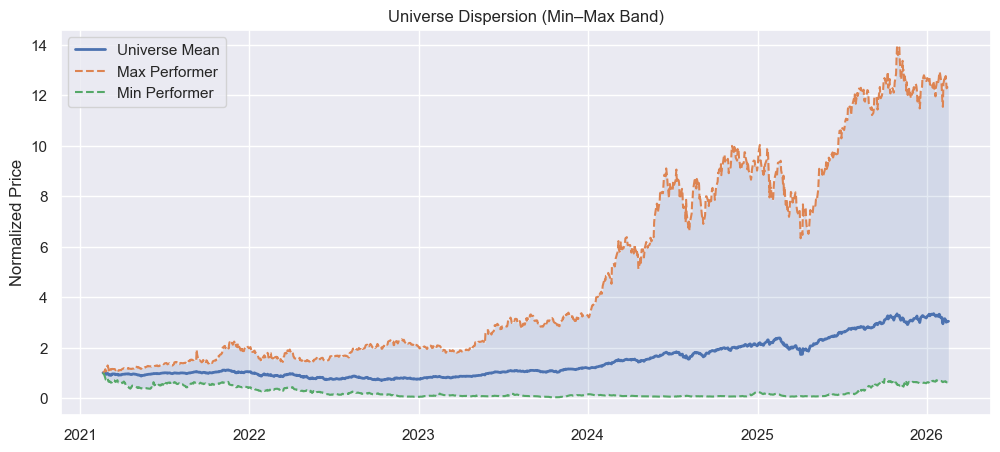

In [4]:
plot_universe_dispersion(prices_filt, normalize="first_valid") # Visualize dispersion of normalized price paths across the dynamic universe

**All-Time High (ATH) and Drawdown Summary:**
  
This table reports each asset’s all-time high price and the current distance from that peak (drawdown).  
A more negative value indicates the asset is further below its historical maximum.

In [5]:
ath_summary(prices_filt) # Summarize each asset's all-time high (ATH) and current drawdown from that peak

,ath_price,ath_date,last_price,last_date,drop_from_ath_pct
Ticker,,,,,
NEE,93.800,2026-02-13,92.71,2026-02-17,-1.162
VOO,639.700,2026-01-27,627.99,2026-02-17,-1.831
TSM,374.090,2026-02-11,364.20,2026-02-17,-2.644
WMT,133.890,2026-02-13,128.85,2026-02-17,-3.764
QQQ,634.952,2025-10-29,601.30,2026-02-17,-5.300
LLY,1108.090,2025-11-25,1036.05,2026-02-17,-6.501
GLDM,106.770,2026-01-29,96.55,2026-02-17,-9.572
NVDA,207.028,2025-10-29,184.97,2026-02-17,-10.655
LTM,68.460,2026-02-02,60.52,2026-02-17,-11.598


# Return Computation

### Simple vs Logarithmic Returns

In this project, we work with **simple (arithmetic) returns** because portfolio construction and performance measurement are naturally defined in terms of wealth changes and weighted averages across assets.

While log-returns are useful for time-series modeling, simple returns are the appropriate choice for Modern Portfolio Theory (MPT), where portfolio returns are computed as weighted sums of individual asset returns.

---

### Definitions

Let $P_t$ denote the price of an asset at time $t$.

**Simple (Arithmetic) Return**
$$
R_t = \frac{P_t}{P_{t-1}} - 1
$$
- Interpreted as the **percentage gain or loss** over the period.
- Example: $R_t = 0.02$ corresponds to a **2% return**.

**Logarithmic (Continuously Compounded) Return**
$$
r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)
$$
- Defined as the logarithm of the gross return.
- For small returns, simple and log returns are numerically very close.

The exact relationship is:
$$
r_t = \ln(1 + R_t), \qquad R_t = e^{r_t} - 1
$$

---

### Time Aggregation

Log-returns are **additive over time**:
$$
r_{1:T} = \sum_{t=1}^{T} r_t
$$

Simple returns compound **multiplicatively**:
$$
1 + R_{1:T} = \prod_{t=1}^{T} (1 + R_t)
$$

This makes log-returns convenient for certain theoretical models, but simple returns more intuitive for tracking portfolio value over time.

---

### Portfolio Returns and MPT (Key Point)

For a portfolio rebalanced at the beginning of each period:
$$
R_t^{(p)} = \sum_i w_i R_{i,t}
$$

This **linearity across assets holds only for simple returns**.  
Log-returns do not satisfy this property in general:
$$
\ln(1 + R_t^{(p)}) \neq \sum_i w_i \ln(1 + R_{i,t})
$$

This linear aggregation is a core assumption behind Modern Portfolio Theory (MPT).

---

### Practical Takeaway

- Portfolio wealth, P&L, cumulative returns, and drawdowns are naturally defined using **simple returns**.
- Log-returns are mainly useful for **time-series modeling** (e.g., GARCH, GBM).
- Since this project focuses on **capital allocation across assets (MPT)**, using **simple returns** ensures portfolio returns and risk measures are computed consistently.

> **If you are tracking money, use simple returns.**

### Methodological Choice

This project uses **simple (arithmetic) returns** instead of log-returns to remain consistent with the assumptions of Modern Portfolio Theory (MPT).  
In MPT, portfolio returns are computed as weighted sums of individual asset returns, a linear aggregation property that holds for simple returns but not for log-returns.  

While log-returns are convenient for time-series modeling and theoretical work, they break the linear relationship required for portfolio weights.  
For this reason, and because this project focuses on **capital allocation across assets**, simple returns are used throughout the analysis.


In [6]:
simple_ret = compute_returns(port,method="simple",dropna="all")
simple_ret

Ticker,NVDA,PLTR,VOO,QQQ,IBIT,GLDM,AVGO,META,MSFT,GOOGL,...,TSM,LLY,NEE,CEG,NFLX,ASTS,RKLB,ONDS,IREN,LTM
Date,,,,,,,,,,,,,,,,,,,,,
2021-02-22,-0.038237,-0.034483,-0.007864,-0.025920,NaN,0.014656,-0.027757,-0.004703,-0.026808,-0.016540,...,-0.022611,-0.001194,-0.038412,NaN,-0.011921,-0.094574,-0.009259,0.050530,NaN,NaN
2021-02-23,-0.014890,-0.044643,0.001265,-0.002977,NaN,-0.001667,-0.009363,0.021242,-0.005288,0.002853,...,-0.033465,0.008969,-0.005193,NaN,0.023174,-0.063927,-0.023364,0.038790,NaN,NaN
2021-02-24,0.025244,-0.013458,0.011061,0.008243,NaN,-0.001113,0.019029,-0.005830,0.005487,0.011499,...,0.024787,0.010075,-0.012716,NaN,0.013293,-0.055488,-0.000957,0.045556,NaN,NaN
2021-02-25,-0.082178,-0.092080,-0.023989,-0.034863,NaN,-0.018384,-0.049326,-0.036396,-0.023705,-0.032565,...,-0.047619,-0.003423,0.009336,NaN,-0.012125,-0.098128,-0.011494,-0.071429,NaN,NaN
2021-02-26,0.030584,-0.002504,-0.005491,0.004188,NaN,-0.024404,0.027802,0.011504,0.014804,0.002956,...,-0.000476,0.005250,-0.007832,NaN,-0.014359,-0.009306,-0.006783,-0.040769,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-10,-0.007893,-0.023791,-0.002805,-0.004639,-0.028422,-0.009942,-0.010176,-0.009598,-0.000798,-0.017699,...,0.018289,-0.018829,0.015087,-0.003711,0.009083,-0.057286,-0.050237,-0.063830,-0.069773,-0.056901
2026-02-11,0.008009,-0.027453,-0.000141,0.002682,-0.017449,0.010946,0.006815,-0.003027,-0.021536,-0.023919,...,0.033655,-0.009551,0.005835,0.021059,-0.031505,0.006752,-0.033458,-0.046488,-0.006056,0.003434
2026-02-12,-0.016364,-0.048275,-0.015495,-0.020339,-0.032384,-0.033972,-0.033814,-0.028234,-0.006257,-0.006303,...,-0.016012,0.022715,0.006239,-0.002637,-0.047224,-0.151671,-0.051853,-0.028169,-0.061870,-0.002281


# Active Investment Universe

**Note:**<br>
We use _prices_filt_ for Exploratory Data Analysis. For Modern Portfolio Theory inputs, we define an active universe based on a minimum number of return observations (_tickers_active_), and compute $\mu$ and $\Sigma$ using this investable universe.

### Active Universe (Returns)

To ensure stable and comparable estimates of expected returns and covariances, we restrict the analysis to assets with a minimum number of available return observations.

Let $N_i$ denote the number of non-missing daily returns for asset $i$.  
We define the active universe as:

$$
\mathcal{U} = \{ i \; | \; N_i \geq N_{\min} \}
$$

where $$N_{\min} = 252$$ corresponds to approximately one trading year.

Assets that do not meet this requirement are temporarily excluded from the MPT inputs (mean returns and covariance matrix). This maintains numerical stability while preserving a dynamic universe that evolves over time.

In [7]:
# Select assets with sufficient return history for MPT inputs
min_obs = 252 # 252 is the approximate number of trading days in a year
n_obs = simple_ret.count()
tickers_active = n_obs[n_obs>=min_obs].index

ret_mpt = simple_ret[tickers_active] # Returns matrix restricted to the active universe

print(f'There are {len(tickers_active)} assets that we are considering for the portfolio analysis')
 
coverage_df = (n_obs.loc[tickers_active].sort_values().rename("Number of Observations").reset_index().rename(columns={"index": "ticker"}))
coverage_df # Quick check of coverage for selected assets

There are 28 assets that we are considering for the portfolio analysis


,Ticker,Number of Observations
0,LTM,391
1,IBIT,525
2,CEG,1022
3,IREN,1064
4,QQQ,1253
5,NVDA,1253
6,VOO,1253
7,PLTR,1253
8,MSFT,1253
9,GOOGL,1253


# Annualized return and Volatility

## Why We Annualize Returns and Volatility (MPT Intuition)

In MPT, we want portfolio inputs that are easy to interpret and comparable across assets. Since our data is daily, we convert (“annualize”) the main quantities to a one-year scale.

### Why annualize returns?

A daily expected return is small and not directly comparable to the typical way performance is reported (yearly).  
If returns are reasonably stable over time, the expected return over many days is the sum of expected daily returns, so we approximate:

$$
\mu_{\text{annual}} = \mu_{\text{daily}} \times 252
$$

where 252 is the approximate number of trading days in a year.

### Why is expected return the mean?

The expected return is the long-run average outcome of a random variable. In practice, we do not know the true expectation, so we estimate it using the sample mean of historical daily returns:

$$
\mu_{\text{daily}} \approx \frac{1}{T}\sum_{t=1}^{T} r_t
$$

This is the standard estimator because it is a simple and consistent way to approximate the “typical” daily return.

### Why use variance/standard deviation for risk?

In MPT, risk is defined as uncertainty around the expected return. Variance measures how spread out returns are around their mean:

$$
\text{Var}(r) = \mathbb{E}\left[(r - \mu)^2\right]
$$

Standard deviation (volatility) is the square root of variance:

$$
\sigma = \sqrt{\text{Var}(r)}
$$

We use variance/volatility because it provides a single, tractable measure of dispersion that:
- penalizes larger deviations more strongly (squared deviations),
- leads to a mathematically convenient optimization problem (mean–variance),
- allows portfolio risk to be computed directly from asset covariances.

### Why does volatility scale with $\sqrt{252}$?

If daily returns are approximately i.i.d., variances add over time:

$$
\sigma_{\text{annual}}^2 = \sigma_{\text{daily}}^2 \times 252
$$

so volatility becomes:

$$
\sigma_{\text{annual}} = \sigma_{\text{daily}} \times \sqrt{252}
$$

This keeps expected return and risk on the same annual scale when building the efficient frontier.


In [8]:
trading_days = 252 # 252 is the approximate number of trading days in a year

mu = ret_mpt.mean() * trading_days
Sigma = ret_mpt.cov() * trading_days

# Build a clean table with asset-level MPT inputs
mpt_inputs_df = (pd.DataFrame({"Ticker": mu.index, "Expected Annual Return (mu)": mu.values, "Annual Volatility (sigma)": np.sqrt(np.diag(Sigma.values))})
                 .sort_values("Expected Annual Return (mu)", ascending=False) .reset_index(drop=True))

mpt_inputs_df

,Ticker,Expected Annual Return (mu),Annual Volatility (sigma)
0,ASTS,0.855381,1.106561
1,IREN,0.811586,1.196992
2,RKLB,0.670595,0.780820
3,LTM,0.643860,0.293248
4,NVDA,0.641620,0.521240
5,CEG,0.616470,0.494158
6,ONDS,0.582562,1.138450
7,PLTR,0.519594,0.659116
8,AVGO,0.496309,0.426230
9,LLY,0.391441,0.321181


In [9]:
# Basic sanity checks on MPT inputs
print("Number of assets:", mu.shape[0])
print("NaNs in mu:", mu.isna().sum())
print("NaNs in Sigma:", Sigma.isna().sum().sum())

Number of assets: 28
NaNs in mu: 0
NaNs in Sigma: 0


At this stage, returns and risk are still computed at the **asset level**. Portfolio-level return and volatility will only be obtained once portfolio weights are specified.

Here, $\mu$ represents the **expected annual return of each asset**, while $\sigma$ denotes each asset’s **annual standard deviation of returns (volatility)**.  

The covariance matrix $\Sigma$ captures how assets move relative to each other and, along with $\mu$, provides the direct inputs to construct the Efficient Frontier and solve portfolio optimization problems (e.g., minimum variance, maximum Sharpe ratio) in the next notebook.
